# Final Python Report

## Part 1. Continue the Existing Jupyter Notebook (below)

### 1. Continue Using Your Approved Dataset
Use the same dataset submitted in the previous assignment unless you received permission to change it. Your dataset must still satisfy all previously stated requirements:

* Real-world data only
* No fabricated, simulated, or AI-generated datasets
* At least 500 observations
* At least 10 variables
* Appropriate mix of continuous and categorical variables

We are using a dataset that covers all players in the NBA (567 rows). The columns (variables) are player, team, conference, position (grouped), age, games_played, minutes_per_game, rebounds_per_game, assists_per_game, points_per_game, salary_filled, born.

This data came from Spotrac (https://www.spotrac.com/nba/contracts)

### 2. Select Two Variables of Interest
Your team must select:

* One primary continuous variable
* One additional variable of interest (continuous or categorical)
* These variables should be meaningful and potentially useful for future analyses later in the course.

Examples:

* Airbnb nightly price & room type
* Customer spending & membership status
* Hospital charges & insurance type
* Briefly explain why your team selected these two variables.

Primary continuous variable - NBA player 'salary_filled'

Additional variable of interest - US/international status 'born'

We chose these two variables to analyze if it's mostly Americans that are being valued the highest or if its more international like the NBA brands itself to be.

Salary is our main variable of interest due to its wide range and skew. We want to analyze different variables against salary to see how those variables impact salary and the weight of each one. It also is very interesting to see how players are valued and find any patterns/correlations within contract value.

The NBA has seen a significant rise in international talent in recent years (MVP awards, All-Star selections, top draft picks) increasingly being international players. Ex: (Luka Doncic, Victor Wembanyama, etc.)



### 3. AI-Assisted Data Import & DataFrame Creation
Using Python and AI tools (e.g., ChatGPT, Copilot, Gemini, Claude, etc.):

Import your dataset into Python

Create a properly structured pandas DataFrame (see link for further details)

Display and inspect the dataset using commands such as:
* .head()
* .info()
* .describe()

Your submission should clearly show the Python code used in the notebook.

In [1]:
import pandas as pd
# This part, I also needed help with AI to get the 'path' correct.
# Updated to load the dataset directly from this repo's data/ folder
# instead of Google Drive, so the notebook is portable.

# Load it into pandas
df = pd.read_excel('data/nba_contracts_performance_final_v2.xlsx')

# Verify it loaded correctly
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 566 entries, 0 to 565
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   player             566 non-null    str    
 1   team               566 non-null    str    
 2   conference         566 non-null    str    
 3   position_group     566 non-null    str    
 4   age                566 non-null    int64  
 5   games_played       566 non-null    int64  
 6   minutes_per_game   566 non-null    float64
 7   rebounds_per_game  566 non-null    float64
 8   assists_per_game   566 non-null    float64
 9   points_per_game    566 non-null    float64
 10  salary_filled      566 non-null    int64  
 11  born               566 non-null    str    
dtypes: float64(4), int64(3), str(5)
memory usage: 53.2 KB


,age,games_played,minutes_per_game,rebounds_per_game,assists_per_game,points_per_game,salary_filled
count,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,5.660000e+02
mean,25.931095,46.392226,19.839929,3.617491,2.162898,9.273145,9.326170e+06
std,4.240202,24.859852,8.939620,2.360395,1.798486,6.412694,1.281956e+07
min,19.000000,1.000000,1.600000,0.000000,0.000000,0.000000,1.319700e+04
25%,23.000000,25.000000,12.350000,1.900000,0.900000,4.300000,1.031960e+06
50%,25.000000,53.000000,20.400000,3.150000,1.600000,8.000000,3.634153e+06
75%,28.000000,68.000000,27.200000,4.900000,2.900000,12.650000,1.159352e+07
max,41.000000,82.000000,38.000000,12.900000,10.700000,33.500000,5.960682e+07


In [2]:
# You'll notice above that the last two columns didn't work correctly,
# so I asked Claude to help me fix the issue. Claude helped me
# fix the bugs with the salary_filled and born variables (unnamed 12 and 13)
# See Claude notes below this cell

# Clean up column names (strip hidden whitespace, e.g. ' salary_filled ')
df.columns = df.columns.str.strip()

# Clean up column names (strip hidden whitespace, e.g. ' salary_filled ')
df.columns = df.columns.str.strip()

# Drop the fully-empty "Unnamed" columns (leftover blank columns from the CSV)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Convert salary_filled from currency text ("$45,999,660.00") into a real number
df['salary_filled'] = df['salary_filled'].replace(r'[\$,]', '', regex=True).astype(float)

# Convert salary_filled from currency text ("$45,999,660.00") into a real number
df['salary_filled'] = df['salary_filled'].replace(r'[\$,]', '', regex=True).astype(float)

df.head()
df.info()
pd.set_option('display.float_format', '{:,.2f}'.format)
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 566 entries, 0 to 565
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   player             566 non-null    str    
 1   team               566 non-null    str    
 2   conference         566 non-null    str    
 3   position_group     566 non-null    str    
 4   age                566 non-null    int64  
 5   games_played       566 non-null    int64  
 6   minutes_per_game   566 non-null    float64
 7   rebounds_per_game  566 non-null    float64
 8   assists_per_game   566 non-null    float64
 9   points_per_game    566 non-null    float64
 10  salary_filled      566 non-null    float64
 11  born               566 non-null    str    
dtypes: float64(5), int64(2), str(5)
memory usage: 53.2 KB


,age,games_played,minutes_per_game,rebounds_per_game,assists_per_game,points_per_game,salary_filled
count,566.00,566.00,566.00,566.00,566.00,566.00,566.00
mean,25.93,46.39,19.84,3.62,2.16,9.27,"9,326,169.58"
std,4.24,24.86,8.94,2.36,1.80,6.41,"12,819,559.64"
min,19.00,1.00,1.60,0.00,0.00,0.00,"13,197.00"
25%,23.00,25.00,12.35,1.90,0.90,4.30,"1,031,960.25"
50%,25.00,53.00,20.40,3.15,1.60,8.00,"3,634,153.00"
75%,28.00,68.00,27.20,4.90,2.90,12.65,"11,593,518.75"
max,41.00,82.00,38.00,12.90,10.70,33.50,"59,606,817.00"


### Claude Notes

"First, the column name itself has hidden whitespace — it's actually ' salary_filled ' (with a leading and trailing space) rather than salary_filled, which is why referencing it directly was failing.

Second, once I fixed that, I could see the real values: salary_filled is stored as text strings like "$45,999,660.00" (with a dollar sign, commas, and decimals), so pandas reads it as an object (string) column instead of a number — that's the "doesn't work correctly" part, since you can't do math/stats on it as-is. Meanwhile born actually just contains "US" / "INT" values — it's your US/international categorical variable, not a birth date, and it's already loading correctly as text, so nothing needs to change there."

### 4. Descriptive Statistics
For the two selected variables, compute and interpret appropriate descriptive statistics. Examples may include:

* Mean
* Median
* Standard deviation
* Minimum / maximum
* Frequency tables
* Value counts

Your notebook should include:

* Python code
* Output
* Short explanations or interpretations

In [3]:
#I used AI here to help me see how I can import my CSV data so I can
#do the analysis. I also used it to help me clean up the charts and tables
#so it is easier for us to read rather than without the display and markdown
#functions

import pandas as pd
from IPython.display import display, Markdown

# Load the dataset directly from this repo's data/ folder (updated from Drive)
df = pd.read_excel("data/nba_contracts_performance_final_v2.xlsx")
df.columns = df.columns.str.strip()
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df['salary_filled'] = df['salary_filled'].replace(r'[\$,]', '', regex=True).astype(float)

# Descriptive statistics for our continuous variable only which is salary
display(Markdown("### Descriptive Statistics — salary_filled"))
display(df[['salary_filled']].describe().round(2))

# frequency tables for salary and international status
display(Markdown("### Frequency Table — salary_filled"))
salary_counts = df['salary_filled'].value_counts().reset_index()
salary_counts.columns = ['salary_filled', 'count']
display(salary_counts)

display(Markdown("### Frequency Table — born"))
born_counts = df['born'].value_counts().reset_index()
born_counts.columns = ['born', 'count']
display(born_counts)

print(born_counts)
print(df['born'].value_counts(normalize=True).round(3) * 100)

### Descriptive Statistics — salary_filled

,salary_filled
count,566.00
mean,"9,326,169.58"
std,"12,819,559.64"
min,"13,197.00"
25%,"1,031,960.25"
50%,"3,634,153.00"
75%,"11,593,518.75"
max,"59,606,817.00"


### Frequency Table — salary_filled

,salary_filled,count
0,"85,300.00",38
1,"636,435.00",16
2,"2,221,677.00",14
3,"1,955,377.00",14
4,"3,634,153.00",13
...,...,...
367,"234,091.00",1
368,"188,932.00",1
369,"212,145.00",1
370,"5,429,520.00",1


### Frequency Table — born

,born,count
0,US,427
1,INT,139


  born  count
0   US    427
1  INT    139
born
US    75.40
INT   24.60
Name: proportion, dtype: float64


### Commentary on the Outputs

The salary mean (9.33M) is way higher than the median of (3.63) which shows that salary as a whole is right-skewed. The standard deviation (12.8M) is huge and confirms wide variability as well as the range. Median is the more representative variable in our data set.

We also see in the salary frequency table that salary is indeed continuous. This table isn't particulary helpful, and it might be more insightful if we grouped salaries.

The "born" frequency table tells us the split between players that were born in the US vs. internationally. This will be important once we start running more analysis. For example, if international players are getting paid way more on average than USA, we can wait to draw conclusions right away because we understand the context and nature of our data.

### 5. Probability Distribution Exploration
Explore the probability distribution of the two selected variables. Depending on the variable type, this may include:

* Histograms
* Bar charts
* Relative frequencies
* Probability calculations
* Distribution shape observations

Include brief written observations about what you notice from the distributions.

In [4]:
# Used Claude to find out why the dataset would not load even though I had the correct file path
# Received an encoding prompt to help figure out the loading issue
# Updated to load directly from this repo's data/ folder instead of Google Drive

import pandas as pd

df = pd.read_excel("data/nba_contracts_performance_final_v2.xlsx")

# Used same conversion metrics from preivous cell
# Clean up column names (strip hidden whitespace, e.g. ' salary_filled ')
df.columns = df.columns.str.strip()

# Drop the fully-empty "Unnamed" columns (leftover blank columns from the CSV)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Convert salary_filled from currency text ("$45,999,660.00") into a real number
df['salary_filled'] = df['salary_filled'].replace(r'[\$,]', '', regex=True).astype(float)

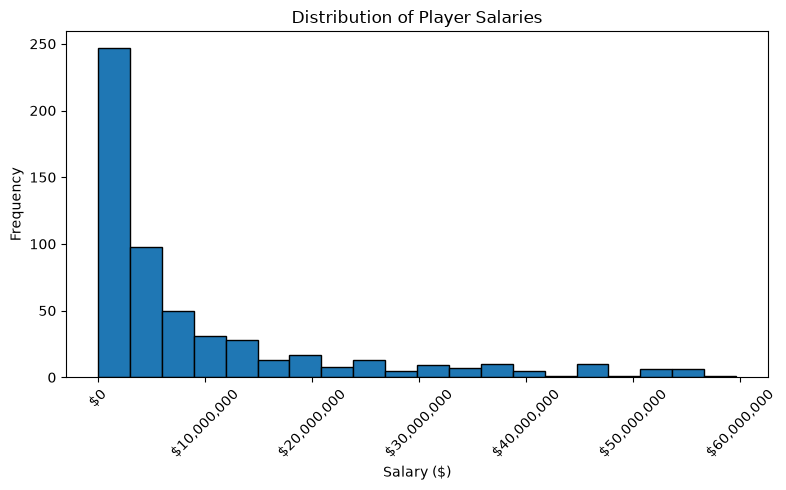

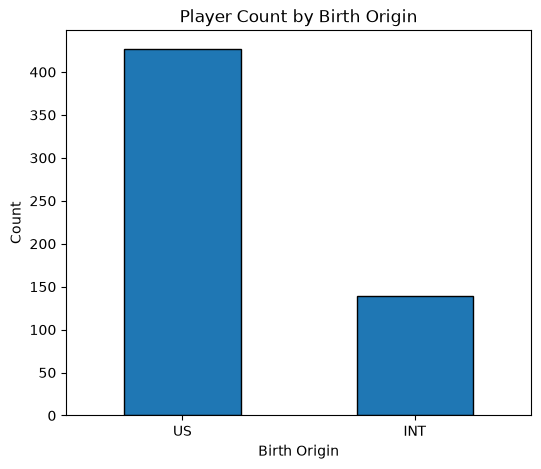



Relative Frequencies (born):
born
US    0.75
INT   0.25
Name: proportion, dtype: float64


Relative Frequencies (salary_filled, binned):
salary_filled
(-46396.62, 11931921.0]    0.75
(11931921.0, 23850645.0]   0.12
(23850645.0, 35769369.0]   0.06
(35769369.0, 47688093.0]   0.05
(47688093.0, 59606817.0]   0.02
Name: proportion, dtype: float64


Probability calcualtions (Salary_Filled)
P(salary > $10,000,000) = 0.2845
P(salary <= $10,000,000) = 0.7155


Conditional Probabilities
P(born = INT AND salary > $10,000,000) = 0.0742
P(salary > $10,000,000 | born = INT) = 0.3022
P(salary > $10,000,000 OR born = INT) = 0.4558


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Claude was used to help set up the visualizations and work out the logic in the conditional statements
# Histogram: salary_filled
plt.figure(figsize=(8, 5))
plt.hist(df['salary_filled'], bins=20, edgecolor='black')
plt.title('Distribution of Player Salaries')
plt.xlabel('Salary ($)')
plt.ylabel('Frequency')

# Format x-axis to show full dollar amounts instead of scientific notation
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# Bar chart: born (US vs INT)
print("\n")
born_counts = df['born'].value_counts()
plt.figure(figsize=(6, 5))
born_counts.plot(kind='bar', edgecolor='black')
plt.title('Player Count by Birth Origin')
plt.xlabel('Birth Origin')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# Relative frequencies for born
print("\n")
born_relative_freq = df['born'].value_counts(normalize=True)
print("Relative Frequencies (born):")
print(born_relative_freq)

# Relative frequencies for salary_filled using bins
print("\n")
salary_bins = pd.cut(df['salary_filled'], bins=5)
salary_rel_freq = salary_bins.value_counts(normalize=True).sort_index()
print("Relative Frequencies (salary_filled, binned):")
print(salary_rel_freq)

# Probability calculations: salary_filled
print("\n")
print("Probability calcualtions (Salary_Filled)")
threshold = 10_000_000
prob_above_10m = (df['salary_filled'] > threshold).mean()
prob_below_10m = (df['salary_filled'] <= threshold).mean()
print(f"P(salary > ${threshold:,}) = {prob_above_10m:.4f}")
print(f"P(salary <= ${threshold:,}) = {prob_below_10m:.4f}")

# Joint/conditional probability example: high earners who are international
print("\n")
print ("Conditional Probabilities")
prob_int_and_high = ((df['born'] == 'INT') & (df['salary_filled'] > threshold)).mean()
print(f"P(born = INT AND salary > ${threshold:,}) = {prob_int_and_high:.4f}")

# Conditional: given a player is international, probability they earn > $10M
prob_high_given_int = df[df['born'] == 'INT']['salary_filled'].gt(threshold).mean()
print(f"P(salary > ${threshold:,} | born = INT) = {prob_high_given_int:.4f}")

# Union probability: P(salary > $10M OR born = INT)
# P(A or B) = P(A) + P(B) - P(A and B)
prob_int = (df['born'] == 'INT').mean()
prob_union_high_or_int = prob_above_10m + prob_int - prob_int_and_high
print(f"P(salary > ${threshold:,} OR born = INT) = {prob_union_high_or_int:.4f}")

### Commentary on findings

In analyzing the results, it is clear that the bulk of players in our dataset earn less than 10 million. Additionally, 75% of players were born in the US, with the remaining 25% making up the international population. Looking at the joint probability, the likelihood that a player is both internationally born and earns more than 10 million is only 7%. The probability that a player either earns more than 10 million or is internationally born is about 45.6%. Seperately, the probability that an international player earns more than 10 million is about 30.2%. This is very close to the 28.45% probability that any player, regardless of origin, earns more than $10 million. These findings show that our salary data is heavily right-skewed, while the born distribution is imbalanced but not extreme.

### 6. AI Usage Documentation
You are encouraged to actively use AI tools throughout this assignment.

Whenever AI helps you:

* write code,
* debug errors,
* understand concepts,
* clean data, or improve analysis,

Document this in your notebook using:

* Markdown cells, or
* Python comments
* If you learned something new through interacting with AI,briefly describe it.

Examples:

* “AI suggested using .value_counts(normalize=True) to calculate probabilities.”
* “We learned how to handle missing values using pandas.”
* “AI helped explain the difference between categorical and continuous variables.”

Throughout this assignment, we used Claude to help with data loading, cleaning, and analysis. AI helped us convert the Excel workbook into a CSV and upload it to Drive, and helped us identify a UnicodeDecodeError caused by the file's encoding. We learned that setting encoding='latin1' in pd.read_csv() resolves this. Claude also helped us fix formatting issues in the salary_filled and born columns, teaching us how to strip currency symbols using regex and convert text to numeric data with .astype(float). Finally, Claude helped us build our visualizations and work through the logic for our conditional statements. We learned how to calculate probabilities using boolean masks in pandas.

### 7. Reflection on AI-Assisted Analysis
At the end of the notebook, include a short reflection section (approximately 1–2 paragraphs) discussing:

* How your team used AI tools
* What AI was helpful for
* What limitations or problems you encountered
* Whether AI-generated code always worked correctly
* What your team still needed to understand or verify on your own
* The purpose of this reflection is to help you think critically about the role of AI in programming and data analytics

Our team mostly used AI as an extra set of eyes to help get the information that we needed, like importing the CSV and pandas. We used it to help put our information into charts and tables so it is easier to digest. Essentially, it was helpful for us to clean up minor mistakes and formatting issues as well as interacting with pandas. It helped us clean up the things we do know and helped expand to some other functions that we were not as clear on.

However, a big problem was when we put a single question into Claude like: "how can I make a chart with this data?" and Claude completely writing the whole code, going over a lot of things we have never talked about in class. For the most part, the code did work correctly with a bit of cleaning up on our part for small things like column labels. We still needed to verify the outputs to make sure that they made sense and lined up with the same numbers when we did it in Excel, to make sure our code was outputting the correct values.


## Part 2. Final Report Section

### Q2. Develop and Test Two Hypotheses

In [6]:
#loading the data back in
# Updated to load directly from this repo's data/ folder instead of Google Drive

import pandas as pd

df = pd.read_excel("data/nba_contracts_performance_final_v2.xlsx")

In [7]:
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

alpha = 0.05

# Hypothesis 1: Average salary differs between US born and international players
# H0: mean salary (US) = mean salary (INT)
# H1: mean salary (US) != mean salary (INT)
# Method: Two sample t-test, Welch's version (unequal variance)

# I used AI here to help me figure out the right method to test this hypothesis
# as well as help me with the Python syntax so it can do the actual math

us_salary = df[df['born'] == 'US']['salary_filled']
int_salary = df[df['born'] == 'INT']['salary_filled']

t_stat, p_value_1 = stats.ttest_ind(us_salary, int_salary, equal_var=False)

print("Hypothesis 1: Salary by Birth Origin (US vs INT)")
print(f"US mean salary:  ${us_salary.mean():,.2f}")
print(f"INT mean salary: ${int_salary.mean():,.2f}")
print(f"Test statistic (t): {t_stat:.4f}")
print(f"p-value: {p_value_1:.4f}")

if p_value_1 < alpha:
    print(f"Decision: Reject the null hypothesis (p = {p_value_1:.4f} < alpha = {alpha})")
else:
    print(f"Decision: Fail to reject the null hypothesis (p = {p_value_1:.4f} >= alpha = {alpha})")

print("\n" + "="*60 + "\n")

# Hypothesis 2: More than 70% of players in the dataset were born in the US
# H0: p = 0.70 (proportion of US born players is 70%)
# H1: p > 0.70 (proportion of US born players is greater than 70%)
# Method: One sample proportion z

#Used Claude in the same way as listed in hypothesis 1

count_us = (df['born'] == 'US').sum()
n_total = df['born'].count()
hypothesized_p = 0.70

z_stat, p_value_2 = proportions_ztest(count=count_us, nobs=n_total, value=hypothesized_p, alternative='larger')
sample_proportion = count_us / n_total

print("Hypothesis 2: Proportion of US-Born Players")
print(f"Sample proportion (US-born): {sample_proportion:.4f} ({sample_proportion*100:.1f}%)")
print(f"Test statistic (z): {z_stat:.4f}")
print(f"p-value: {p_value_2:.4f}")

if p_value_2 < alpha:
    print(f"Decision: Reject the null hypothesis (p = {p_value_2:.4f} < alpha = {alpha})")
else:
    print(f"Decision: Fail to reject the null hypothesis (p = {p_value_2:.4f} >= alpha = {alpha})")

Hypothesis 1: Salary by Birth Origin (US vs INT)
US mean salary:  $9,139,587.92
INT mean salary: $9,899,337.70
Test statistic (t): -0.5931
p-value: 0.5537
Decision: Fail to reject the null hypothesis (p = 0.5537 >= alpha = 0.05)


Hypothesis 2: Proportion of US-Born Players
Sample proportion (US-born): 0.7544 (75.4%)
Test statistic (z): 3.0077
p-value: 0.0013
Decision: Reject the null hypothesis (p = 0.0013 < alpha = 0.05)


Explanation

Test 1: The sample shows that international players are averaging about $760K more than US born players (9.9 M vs 9.14 M). The t stat (-0.59) is small and the p value (0.5537) is way above the 0.05 threshold. If there was no no difference in average salary between US and international players, we'd see a gap this large about 55% of the time which is way too common to call it a real effect. This makes sense because of our huge variability from earlier, with ST DEV of 12.8M. We fail to reject the null hypothesis. There is not enough statistical evidence to conclude that the average salary differs between US born and international players. The gap we found is well within what we'd expect from random variation.

Test 2: Our sample proportion is 75.4% US born players, and we are testing whether that is meaninfully above the 70% benchmark. The z stat (3.01) and p value (0.0013) tells us this result would happen less than 0.13% of the time if the true proportion was 70%. We reject our null, and there is strong statistical evidence that more than 70% of players in our data set is US born. Practically, this suggests that NBA's domestic talent base is larger than 70% by a good bit, even as itnernational representation grows. It's still interesting considering our results from the first test, because while international players only make up about a quarter of the league, they are making roughly the same, which shows that the international game growing is more about growing presence and visibility rather than a shift on overall roster construction/

### Q3. Confidence Interval Analysis

In [8]:
from scipy import stats

confidence = 0.95
data = df['salary_filled'].dropna()

n = len(data)
mean = data.mean()
std_err = stats.sem(data)          # standard error
degrees_freedom = n - 1

# t-distribution is used bc we don't know the true population std dev, only sample

# I used AI in same way as in question 2, just wanting to see what they thought the
# best method was and how to do the math so we can interpret the results

t_critical = stats.t.ppf((1 + confidence) / 2, degrees_freedom)
margin_of_error = t_critical * std_err

lower_bound = mean - margin_of_error
upper_bound = mean + margin_of_error

print("95% Confidence Interval")
print(f"Sample size: {n}")
print(f"Point estimate: ${mean:,.2f}")
print(f"Margin of error: ${margin_of_error:,.2f}")
print(f"95% CI: (${lower_bound:,.2f}, ${upper_bound:,.2f})")

95% Confidence Interval
Sample size: 566
Point estimate: $9,326,169.58
Margin of error: $1,058,386.54
95% CI: ($8,267,783.04, $10,384,556.12)


Interpretation

We are 95% confident that the true average NBA player salary falls between $8,267,783.04 and 10,384,556.12. This gives teams a realistic range for what a typical league wide salary looks like. However, given the earlier finding that salary is heavily right skewed, the median may still be a more representative single number for most players.

### Q4. Assumptions & Statistical Validity

Our dataset has 566 players total, split into 427 US-born and 139 international players for the salary comparison. Both sample sizes are about the general rule of thumb (n>=30) needed for the Central Limit Theorem to apply. Salary itself is heavily right skewed which affects the raw data more than our tests, since both the t-test and confidence interval rely on the distribution of the sample mean rather than the individual salaries. The top salaries (up to 59.6 million) are legitimate top end contracts, not errors, so we kept them. They are however very influential in widening the standard deviation and pulling the mean way above the median, which is why our confidence interval is wide causing us to flag the median as more representative of the typical player.

We treated individual players as independent observations, which is a reasonable simplification but not perfect, since teammates share the same salary cap and a team's roster construction can affect what is left over for other players. For the US vs. International comparison, we used Welch's t-test instead of the standard equal-variance test specifically because we couldn't assume equal variance between groups (the international group is much smaller). Overall, the large sample sizes make our tests statistically valid despite the underlying skew, but the main caveats are the non-independence introduced by shared team salary structures and the fact that these results show association, not causation. Differences in salary by birth origin could still be driven by confounders like age, player metrics, or minutes played.

### Q5. Commentary & Business Interpretation

Across our hypothesis tests, confidence interval, and probability analysis, a consistent conclusion is drawn; NBA salary is not meaningfully explained by birth origin alone. We failed to reject the null in hypothesis 1, finding no statistically significant difference between average US-born salary and International salary. This was further reinforced in our probability work showing that international players earn more than 10 million at almost the same rate (30.2%) as the league overall (28.45%). At the same time, our second hypothesis confirmed that the league is still solidly majority US-born (75.4%). All together, international players remain a small portion of the league by headcount, but once a player is on an roster, where they are born does not tell us much about what they get paid given the data. The most surprising part was how large that gap appeared to be in the raw group means (760k) despite turning out to be statistically insignificant. This was a good lesson to show how a difference that might look meaningful in a simple average can just be noise.

From a business standpoint, if the NBA, a team, or media partner is leaning into international stars for marketing and global growth, that strategy is about visibility and storylines rather than those players being paid more or valued higher by the market. We can further conclude that there is no financial reason to be more cautious about signing international prospects over domestic ones, since the smaller international pipeline commands no pay premium or discount. That said, salary is driven far more by age, experience/contract stage, and on-court production. In our tests, we did not control for any of them here, so a young international player and a veteran US-born player are not directly comparable and our dataset skews towards relatively young players overall. Our conclusions describe association, not causation, and our next step would be a regression controlling for age, minutes, and performance stats to isolate whether origin has any independent effect on salary once those factors are held constant.


### Q6. AI Usage

Document meaningful AI usage using markdown cells or comments.

If AI helped you learn something new, solve an issue, or improve your workflow, briefly explain it

**See code comments to learn more about our usage of AI.**

### Q7. Final Written Report

Our question since finding our data set has been: What drives an NBA player's salary, and how well can performance statistics explain it? We combined data from SpotRac, Basketball-Reference, and the NBA. Our dataset contains 566 players from the 2025-2026 season, combining variables including roster data, performance metrics, and contract value.

**Key Findings**
*   **Salary is extremely skewed**. Mean salary (\~9 million) is nearly triple the median (\~3.6 million). A small group of stars pull the average way up (ex: Steph Curry, Lebron James, etc).
*   **Performance predicts pay**; mostly scoring and playmaking. Our final regression model (adjusted R^2 = 0.615) explains \~61.5% of variation in player contract value. Our model found points per game (\~1.79M per additional point) and assists (\~1.28M per additional assist) as the strongest, most reliable drivers of salary, which makes sense logically, as the players contributing the most on the scoreboard and on the court are typically the ones making the most money.
*   **Statistical confirmation:** Our hypothesis test and confidence intervals confirmed that mean salary is significantly above the median, but the interval's lower bound (\$8.27M) still sits above the median (\$3.63M), reinforcing that the statistical 'average' overstates what a typical player makes.
*   **Negative coefficients:** Minutes per game showed a counterintuitive **negative** relationship with salary, which we attribute to multicollinearity (as minutes per game is highly correlated with points per game and assists).
*   **Birth Origin Doesn't Predict Pay:** Despite the NBA's growing international profile, we found no statistically significant salary difference between US-born and international players (p=0.55). At the same time, the league remains solidly majority US-born (75.4%, p=0.0013).


**Practical Implications**
*   Our biggest practical takeaway is that a single 'average salary' metric is a poor benchmark in predicting NBA contracts. Because a small number of high-value stars pull the mean well above what a typical player earns, any decision-maker using the league-wide average (whether for budgeting, negotiation, etc.) will statistically overstate what a 'normal' contract looks like. The median or a percentile-based range (confidence interval) provide a much better frame of reference when determining a 'typical' salary.
*   A second implication is that on-court performance, specifically points per game and assists per game, have the biggest statistical impact in determining player salary.
*   A third implication is that birth origin, despite being highly visible in NBA marketing, has no meaningful impact on determining salary. Any percieved pay gap regarding international status should be treated as noise rather than a real market indicator.




**Potential Business Decisions**
*   **Contract Negotiation and Valuation:** front offices can anchor negotiations to points and assists per game as the most reliable and defensible value drivers (rather than minutes per game or age) when determining salary and negotiating with agents/players.
*   **Payroll and Salary Cap Planning:** teams should budget against the median and the 25th-75th percentile range rather than the league wide mean, since the mean is inflated by high-value superstars and is not accurate to the majority of players make in terms of total roster costs.
*   **Roster Construction:** because \~38.5% of salary variation is still unexplained by our model, decision-makers should treat performance stats as a strong predictor of salary but not the end-all be-all. There are other variables not included in our model that may explain some of the variation including injury status, contract stage, and draft pedigree (lottery, G-league, etc).
*   **International Scouting and Marketing Strategy:** because international players earn statistically the same as US-born players, there's no financial reason to value international prospects differently in contract terms. Leaning into international stars is a visibility/marketing strategy, not a valuation or winning-games strategy.




**Recommendations**
*   Use median and percentile-based salary benchmarks instead of the mean when communicating "typical" player pay to stakeholders, given how right-skewed the distribution is.
*   Prioritize points and assists per game as the primary statistical drivers of salary. Treat minutes per game and other variables associated with performace carefully, as there are risks of multicollinearity.
*   Extend this model to include other variables such as injury status, contract stage, experience, college (could be interesting to see which conferences/teams have players making the most money), draft pedigree to see if any of those have an impact on salary.
*   Frame all conclusions as specific to the 2025-2026 season. Salary structures, contracts, free agents, and rookie pay-scale change from year to year, so these findings should be refreshed/updated year to year rather than held over time.












